In [1]:
# ---------------------- Imports ----------------------------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib ipympl

In [3]:
# ---------------------- 3D Simulation ---------------------------

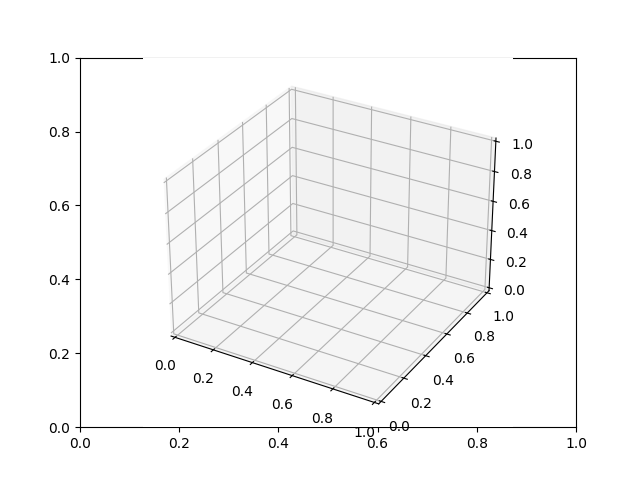

In [5]:
# variables --------------------------------------------
galaxy_num = 8 # number of galaxies in plot
galaxy_size = 15 # dot-size of surrounding galaxies
starting_distance = 10 # how far galaxies can be from initial point

plot_size = 10*(starting_distance**1.5) # Mpc boundary in plot
smoothness = 5 # adjusts time-frames of animation
rotation = True # rotates simulation

time_step = 5000 / smoothness # million years
steps = 13 * smoothness # number of frames
pause_time = 0.4 / smoothness # time between frames


# constants ------------------------------------------------
hubble_constant = 70 # (km/s / Mpc)
Mpc_km_conversion = 3.086 * 10**19
myr_sec_conversion = 10**6 * 365.25 * 24 * 60 * 60


# create random points ----------------------------------------
xs = np.random.randint(-starting_distance, starting_distance, galaxy_num).astype(float) # points dont move when they are ints
ys = np.random.randint(-starting_distance, starting_distance, galaxy_num).astype(float)
zs = np.random.randint(-starting_distance, starting_distance, galaxy_num).astype(float)


# generate frames -------------------------------
fig, ax = plt.subplots()
ax = fig.add_subplot(1, 1, 1, projection='3d')


def animate(step):
    ax.cla()
    
    # central/reference galaxy
    ax.scatter(0, 0, 0, c="yellow", edgecolors='black', label="reference galaxy")
    
    # other galaxies
    ax.scatter(xs, ys, zs, c="red", edgecolors="black", s=galaxy_size, label="surrounding galaxies")

    # plot details
    ax.set_xlim(-plot_size, plot_size)
    ax.set_ylim(-plot_size, plot_size)
    ax.set_zlim(-plot_size, plot_size)
    if rotation:
        ax.view_init(azim=np.pi*step*25/steps, elev=30)
    else:
        ax.view_init(azim=45, elev=30)
    ax.set_title(f"{' '* 50}Time: {step * (time_step/1000)} billion years")
    ax.set_xlabel("Distance (Mpc)")
    ax.set_ylabel("Distance (Mpc)")
    ax.set_zlabel("Distance (Mpc)")
    ax.legend(loc=(-0.15, 1.01))

    # update distances
    for i in range(galaxy_num):

        # set coordinates
        x_coord = xs[i]
        y_coord = ys[i]
        z_coord = zs[i]

        # evaluate distance, velocity, and angle variabels
        magnitude = np.sqrt(x_coord**2 + y_coord**2 + z_coord**2)
        x_dir = x_coord / magnitude
        y_dir = y_coord / magnitude
        z_dir = z_coord / magnitude
        velocity = magnitude * hubble_constant
        
        # calculate new coordinates and update
        xs[i] += velocity * x_dir * time_step * myr_sec_conversion / Mpc_km_conversion
        ys[i] += velocity * y_dir * time_step * myr_sec_conversion / Mpc_km_conversion
        zs[i] += velocity * z_dir * time_step * myr_sec_conversion / Mpc_km_conversion

# Create animation
ani = FuncAnimation(fig, animate, frames=steps, interval=pause_time*1000, repeat=False)


# Show animation  
plt.show()



In [4]:
# to fix error 'too many plots open'
for i in range(20):
    plt.close()